In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


In [3]:
num_of_na=df.isna().sum()
print(num_of_na)
num_of_dub=df.duplicated().sum()
print(num_of_dub)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64
720


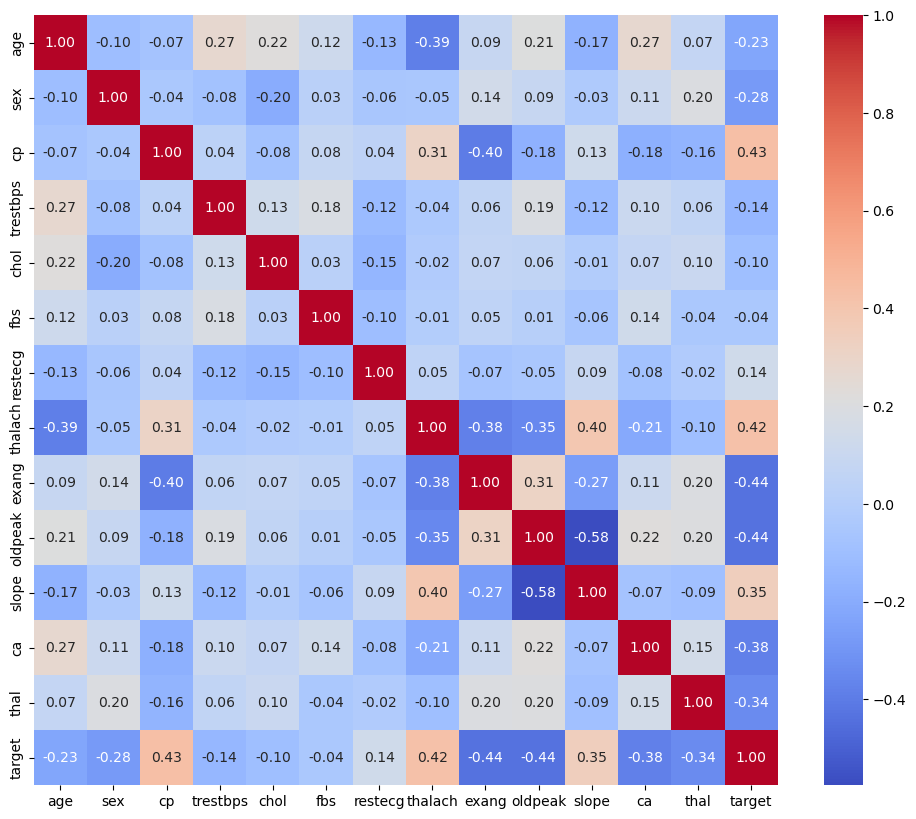

In [4]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

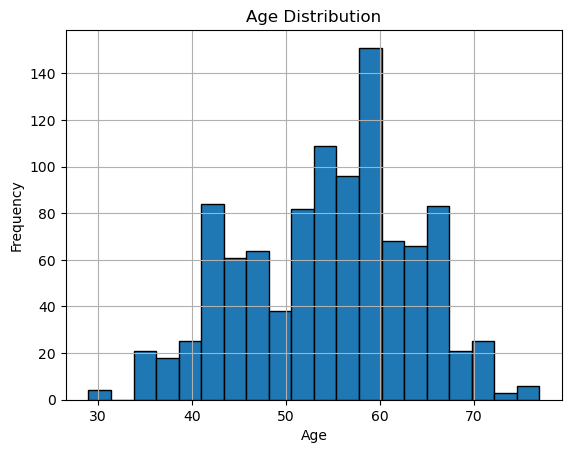

In [5]:
df['age'].hist(bins=20, edgecolor = 'black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

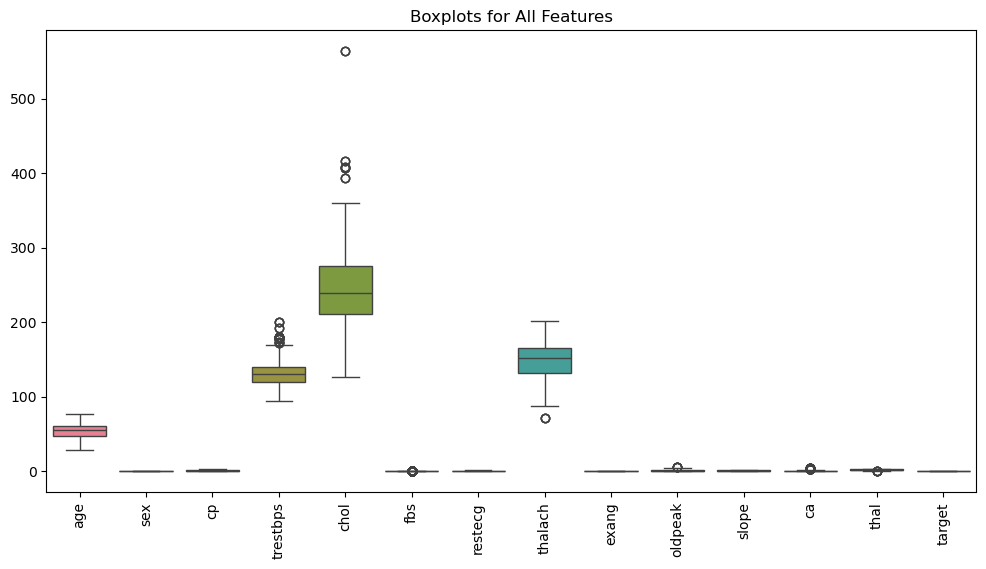

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplots for All Features")
plt.show()

In [7]:
# ====================== إزالة الـ Outliers ======================

print(f"عدد الصفوف قبل الحذف: {len(df)}")

# استخدام IQR Method لحذف الـ Outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# تحديد الحدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# حذف الـ Outliers
df_clean = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

print(f"عدد الصفوف بعد حذف الـ Outliers: {len(df_clean)}")
print(f"عدد الصفوف المحذوفة: {len(df) - len(df_clean)}")

# تحديث df
df = df_clean.reset_index(drop=True)

print("\n✅ تم حذف الـ Outliers بنجاح!")
print(f"\nإحصائيات البيانات الجديدة:")
print(df.describe())

عدد الصفوف قبل الحذف: 1025
عدد الصفوف بعد حذف الـ Outliers: 769
عدد الصفوف المحذوفة: 256

✅ تم حذف الـ Outliers بنجاح!

إحصائيات البيانات الجديدة:
              age         sex          cp    trestbps        chol    fbs  \
count  769.000000  769.000000  769.000000  769.000000  769.000000  769.0   
mean    53.431730    0.691808    0.924577  128.685306  242.075423    0.0   
std      9.225098    0.462047    1.019105   15.314066   44.521145    0.0   
min     29.000000    0.000000    0.000000   94.000000  131.000000    0.0   
25%     46.000000    0.000000    0.000000  120.000000  209.000000    0.0   
50%     54.000000    1.000000    1.000000  130.000000  239.000000    0.0   
75%     60.000000    1.000000    2.000000  140.000000  270.000000    0.0   
max     76.000000    1.000000    3.000000  170.000000  360.000000    0.0   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  768.000000  769.000000  769.000000  768.000000  769.000000  769.000000   
mean  

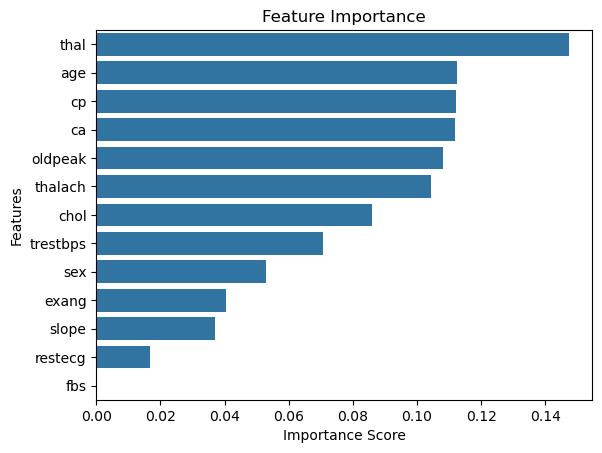

In [8]:
X = df.drop('target', axis=1)
y = df['target']

model = RandomForestClassifier()
model.fit(X, y)

# Get feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Plot
sns.barplot(x=importance, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [9]:
df.drop(columns=['trestbps','fbs','chol', 'restecg'], inplace=True)
num_cols = ['age','thalach','oldpeak']
cat_cols = ['sex', 'cp', 'exang', 'slope', 'ca', 'thal']

In [10]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [11]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_cat = encoder.fit_transform(df[cat_cols])
encoded_cat_df = pd.DataFrame(encoded_cat, columns=encoder.get_feature_names_out(cat_cols))
df = pd.concat([df.drop(columns=cat_cols), encoded_cat_df], axis=1)
df.head()

,age,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,...,exang_1,slope_0,slope_1,slope_2,ca_0,ca_1,ca_2,thal_1,thal_2,thal_3
0,0.489362,0.701754,0.25,0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.872340,0.324561,0.65,0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.680851,0.640351,0.00,0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.617021,0.298246,0.25,1,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.553191,0.500000,0.20,0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [12]:
df.to_csv("clean_data_outliers_duplicated.csv", index=False)

In [13]:
print(df.describe())

              age     thalach     oldpeak      target       sex_0       sex_1  \
count  769.000000  769.000000  768.000000  769.000000  769.000000  769.000000   
mean     0.519824    0.549734    0.243294    0.548765    0.308192    0.691808   
std      0.196279    0.197964    0.262685    0.497940    0.462047    0.462047   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.361702    0.394737    0.000000    0.000000    0.000000    0.000000   
50%      0.531915    0.578947    0.150000    1.000000    0.000000    1.000000   
75%      0.659574    0.701754    0.400000    1.000000    1.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

             cp_0        cp_1        cp_2        cp_3  ...     exang_1  \
count  769.000000  769.000000  769.000000  769.000000  ...  769.000000   
mean     0.483745    0.183355    0.257477    0.075423  ...    0.323797   
std      0.500061    0.387209    0.437529    0.2